# Fig. — Communication–sensing tradeoff / served region

Two panels from a `gamma_sweep`: (a) achieved SINR (left) + weighted sum-SCNR
(right, conditioned on served/feasible trials) vs γ; (b) the served/feasible
**region** vs γ.

Knobs (all default to the paper choices):
- `SINR_METRIC` — `'min'` (worst-user) or `'mean'` (across users) for panel (a).
- `FEASIBILITY` — `'served'` (moderate, ≥η users ≥ γ; **default**), `'outage'`
  (moderate, per-user coverage 1−P_out), or `'strict'` (legacy all-or-nothing).
  This drives **both** panel (b) and the trials the conditional SCNR is taken over.
- `ETA` — coverage fraction η for `'served'`.

**Convention:** the committed PDF is built from the module (`B.build_figure`) for
reproducibility; `build_figure_editable` below is a verbatim editable copy with IEEE
styling for live tweaking. Mutate `ALGORITHM_STYLE` in the setup cell to restyle.

**Compatible experiment:** `gamma_sweep` (`kind=='sweep'`).

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd()
if str(FIG_DIR) not in sys.path:
    sys.path.insert(0, str(FIG_DIR))

import build_fig_cs_tradeoff as B   # loader + collect_curves + build_figure
from cordis.plotting import apply_paper_style, figsize, style_for, save_figure
from cordis.plotting.style import ALGORITHM_STYLE   # tweak here to restyle

USE_TEX = True   # set False on a node without pdflatex
apply_paper_style(use_latex=USE_TEX)
logging.basicConfig(level=logging.INFO, format='%(levelname)-7s %(message)s')

## 1. Load the gamma_sweep run

In [2]:
RESULT_DIR = None   # e.g. 'results/exp_gamma_sweep/20260601_120000'
result, result_dir = B.load_sweep(Path(RESULT_DIR) if RESULT_DIR else None)
print('run:', result_dir)
print('γ grid:', sorted(float(g) for g in result.sweep_results.keys()))

run: /Users/mehdi/Local-Drive/GitHub/CORDIS/results/exp_gamma_sweep/array_52876515_aggregated
γ grid: [0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0]


## 2. Knobs: SINR metric, feasibility definition, conditioning

In [3]:
SINR_METRIC      = 'min'     # 'min' (worst-user) or 'mean' (across users)
FEASIBILITY      = 'outage'  # 'served' (moderate) | 'outage' (moderate) | 'strict'
ETA              = 0.9       # coverage fraction η for 'served'
ONLY             = list(B.PREFERRED)
SCNR_CONDITIONAL = True      # SCNR over served/feasible trials (False -> all trials)
SHOW_SINR_BAND   = True      # IQR band on panel (a)
FEAS_PERCENT     = False     # region rate as % instead of [0,1]

## 3. Numeric summary (region rate by γ)

In [4]:
sinr_metric_name, sinr_label = B._resolve_sinr_metric(SINR_METRIC)
names_data = B.collect_curves(result, only=ONLY, scnr_conditional=SCNR_CONDITIONAL,
                              sinr_metric=sinr_metric_name,
                              feasibility=FEASIBILITY, eta=ETA)
B._print_summary(names_data, feasibility=FEASIBILITY)


coverage (1-Pout) by gamma:
  gamma |   Centralized |   CORDIS-ADMM |  CORDIS-Split
  -----------------------------------------------------
    0.0 |        100.0% |         86.1% |         91.6%
    2.5 |        100.0% |         82.4% |         88.2%
    5.0 |        100.0% |         75.2% |         84.3%
    7.5 |        100.0% |         63.8% |         79.7%
   10.0 |        100.0% |         52.7% |         75.2%
   12.5 |        100.0% |         44.3% |         71.5%
   15.0 |         99.8% |         37.3% |         67.7%


## 4. Canonical build + save (reproducible — from the module)

Writes the committed `paper/figures/fig_cs_tradeoff.pdf` straight from
`B.build_figure`, so the published figure never depends on the editable cell below.

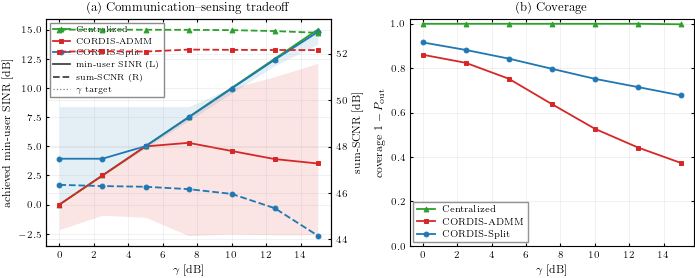

In [5]:
fig = B.build_figure(result, only=ONLY,
                     scnr_conditional=SCNR_CONDITIONAL,
                     show_sinr_band=SHOW_SINR_BAND,
                     feas_as_percent=FEAS_PERCENT,
                     sinr_metric=SINR_METRIC, feasibility=FEASIBILITY,
                     eta=ETA, use_tex=USE_TEX)
plt.show()

## 5. `build_figure_editable` — editable copy (live tweaking)

A verbatim, IEEE-styled copy of `build_figure` you can edit (fonts, line widths,
legend placement, labels) and re-run. Carries the same `sinr_metric` / `feasibility`
/ `eta` options. Copy changes back into `build_fig_cs_tradeoff.py` to make them
permanent / reproducible.

In [6]:
# Bind the module-level names the editable function references.
from typing import Optional, Sequence
SINR_METRIC_DEFAULT = B.SINR_METRIC_DEFAULT
FEASIBILITY_DEFAULT = B.FEASIBILITY_DEFAULT
ETA_DEFAULT         = B.ETA_DEFAULT

In [39]:
def build_figure_editable(result, *, only: Optional[Sequence[str]] = None,
                          scnr_conditional: bool = True,
                          show_sinr_band: bool = True,
                          feas_as_percent: bool = False,
                          sinr_metric: str = SINR_METRIC_DEFAULT,
                          feasibility: str = FEASIBILITY_DEFAULT,
                          eta: float = ETA_DEFAULT,
                          use_tex: bool = True):
    """Editable copy of build_figure with IEEE styling + the moderate-outage /
    min-mean options. Tweak freely here; the *committed* PDF should come from
    B.build_figure (the module) so it stays reproducible."""
    import matplotlib
    if not use_tex:
        matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from cordis.plotting import apply_paper_style, figsize, style_for

    apply_paper_style(use_latex=use_tex)
    if not use_tex:
        matplotlib.rcParams["text.usetex"] = False

    # IEEE standard font sizes
    IEEE_FONT_SIZE = 8
    plt.rcParams.update({
        "font.size": IEEE_FONT_SIZE,
        "axes.labelsize": IEEE_FONT_SIZE + 2,
        "xtick.labelsize": IEEE_FONT_SIZE,
        "ytick.labelsize": IEEE_FONT_SIZE,
        "legend.fontsize": IEEE_FONT_SIZE,
        "legend.title_fontsize": IEEE_FONT_SIZE,
        "figure.titlesize": IEEE_FONT_SIZE,
        "axes.titlesize": IEEE_FONT_SIZE,
    })
    LW = 2
    MARKER_SIZE = 6

    # NEW: resolve the SINR metric (min/mean) and pass the feasibility mode.
    sinr_metric_name, sinr_label = B._resolve_sinr_metric(sinr_metric)
    gammas, names, data = B.collect_curves(
        result, only=only, scnr_conditional=scnr_conditional,
        sinr_metric=sinr_metric_name, feasibility=feasibility, eta=eta)
    xlabel = getattr(result.sweep_axis, "display", None) or r"$\gamma$ [dB]"

    fig, (axA, axB) = plt.subplots(1, 2, figsize=figsize("double", aspect=2.4))
    axA2 = axA.twinx()

    # Panel (a): SINR (left, solid) + SCNR (right, dashed)
    for n in names:
        st = style_for(n)
        color = st.get("color", None)
        marker = st.get("marker", "o")
        d = data[n]
        if d["gamma"]:
            axA.plot(d["gamma"], d["sinr_med"], color=color, marker=marker,
                     ls="-", lw=LW, ms=MARKER_SIZE)
            if show_sinr_band:
                axA.fill_between(d["gamma"], d["sinr_lo"], d["sinr_hi"],
                                 color=color, alpha=0.12, linewidth=0)
        if d["scnr_gamma"]:
            axA2.plot(d["scnr_gamma"], d["scnr_med"], color=color, marker=marker,
                      ls="--", lw=LW, ms=MARKER_SIZE)

    if gammas:
        axA.plot(gammas, gammas, ls=":", color="#888888", lw=LW, zorder=0)

    # NEW: SCNR-axis suffix reflects the conditioning mode.
    scnr_suffix = ({"served": " (served)", "strict": " (feasible)",
                    "outage": ""}[feasibility] if scnr_conditional else "")
    axA.set_xlabel(xlabel)
    axA.set_ylabel(f"achieved {sinr_label} [dB]")
    axA2.set_ylabel("weighted-sum SCNR [dB]" + scnr_suffix)
    # axA.set_title("(a) Communication-sensing tradeoff")
    axA.grid(True, alpha=0.3)

    # Legend: algorithm colors + linestyle key (solid=SINR, dashed=SCNR).
    algo_handles = [Line2D([0], [0], color=style_for(n).get("color"),
                           marker=style_for(n).get("marker", "o"),
                           ls="-", lw=LW, ms=MARKER_SIZE,
                           label=style_for(n).get("label", n))
                    for n in names]
    key_handles = [
        Line2D([0], [0], color="#444444", ls="-", lw=LW, label=f"{sinr_label} (L)"),
        Line2D([0], [0], color="#444444", ls="--", lw=LW, label="w-sum SCNR (R)"),
        # Line2D([0], [0], color="#888888", ls=":", lw=0.9, label=r"$\gamma$ target"),
    ]
    axA.legend(handles= key_handles, bbox_to_anchor=(0.51, 0.55), # algo_handles / (0.51, 0.45) for 'min' metric
               loc="best", ncol=1, framealpha=0.9)

    # Panel (b): served/feasible region vs gamma (NEW: mode-aware y-label)
    region_ylabel = ({
        "served": rf"served-trial rate ($\eta={eta:g}$)",
        "outage": r"coverage $1-P_{\mathrm{out}}$",
        "strict": "feasibility rate",
    }[feasibility]) + (" [%]" if feas_as_percent else "")
    scale = 100.0 if feas_as_percent else 1.0
    for n in names:
        st = style_for(n)
        d = data[n]
        if d["feas_gamma"]:
            axB.plot(d["feas_gamma"], np.asarray(d["feas"]) * scale,
                     color=st.get("color"), marker=st.get("marker", "o"),
                     ls="-", lw=LW, ms=MARKER_SIZE, label=st.get("label", n))
    axB.set_xlabel(xlabel)
    axB.set_ylabel(region_ylabel)
    axB.set_ylim(0, (100 * 1.05) if feas_as_percent else 1.05)
    # axB.set_title("(b) Served region")
    axB.grid(True, alpha=0.3)
    axB.legend(loc="best")

    fig.tight_layout()
    return fig

## 6. Render the editable copy

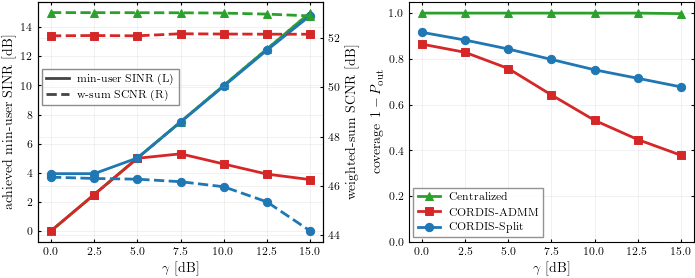

In [40]:
fig = build_figure_editable(result, only=ONLY,
                              scnr_conditional=SCNR_CONDITIONAL,
                              show_sinr_band=False,
                              feas_as_percent=FEAS_PERCENT,
                              sinr_metric='min',    # 'min' (worst-user) or 'mean' (across users)
                              feasibility='outage', eta=1,
                              use_tex=USE_TEX)
plt.show()

## 7. Save to `paper/figures/`

Writes the committed PDF + a PNG preview. (Re-run the headless build any time with
`python3 build_fig_cs_tradeoff.py`.)

In [41]:
tag = '_min'
out_stem = FIG_DIR.parents[1] / 'figures' / str('fig_cs_tradeoff' + tag)
paths = save_figure(
    fig, out_stem, formats=('pdf', 'png'),
    metadata={'Figure': 'fig_cs_tradeoff', 'SinrMetric': sinr_metric_name,
              'Feasibility': (f'{FEASIBILITY}(eta={ETA:g})' if FEASIBILITY=='served' else FEASIBILITY),
              'Run': result_dir.name})
for p in paths:
    print('wrote', p)

wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_cs_tradeoff_min.pdf
wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_cs_tradeoff_min.png
